In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import PatchForagingDDM, create_prior
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_inference import train_snle, infer_parameters_snle
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_utils import plot_training_history

SNLE TRAINING FOR PATCH-LEVEL INFERENCE
Generating 20000 training samples (mode=multi)...


  0%|          | 20/20000 [00:00<01:40, 199.30it/s]


First sample check:
  theta: tensor([1.1389, 0.4262, 0.6046])
  summary_stats: tensor([ 1.3865,  0.4234,  1.3333,  0.5022,  0.2533,  0.4378, 19.0000, 75.0000])
  has NaN: False


100%|██████████| 20000/20000 [00:42<00:00, 473.68it/s]



Number of samples with NaN: 0/20000
Training data shape: theta=torch.Size([20000, 3]), x=torch.Size([20000, 8])
Multi-patch aggregate stats (8 features): mean_time, std_time, mean_stops, std_stops, mean_rewards, std_rewards, total_rewards, num_patches

Training SNLE (multi mode)...
 Training neural network. Epochs trained: 51
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 51
        Best validation performance: -20.9248
        -------------------------
        

SNLE training complete (multi mode)!
Epochs trained: 51
Final train loss: -20.2535
Final validation loss: -19.9141
Best validation loss: -20.9248


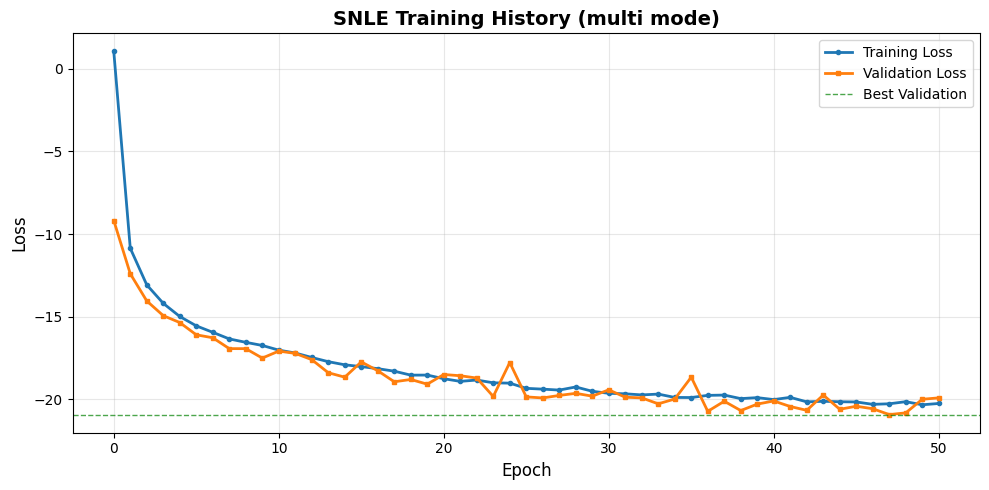


Training Diagnostics:
Epochs trained:        51
Final training loss:   -20.2535
Final validation loss: -19.9141
Best validation loss:  -20.9248
Train-val gap:         0.3394

✓ Train-val gap looks reasonable


In [ ]:
torch.manual_seed(1)
    
# Setup
simulator = PatchForagingDDM()
prior = create_prior()

print("="*60)
print("SNLE TRAINING FOR PATCH-LEVEL INFERENCE")
print("="*60)

# Train multi-patch model
likelihood_estimator_multi, inference_multi, x_mean_multi, x_std_multi, history_multi = train_snle(
    simulator, prior, num_simulations=200000, window_sites=100, mode='multi'
)

# Plot training history
plot_training_history(history_multi, mode='multi')

In [3]:
print("\n" + "="*60)
print("TESTING INFERENCE")
print("="*60)

# Test on a simulated patch
true_theta = torch.tensor([0.4, 0.2, 0.3])
print(f"\nTrue parameters: {true_theta}")

# Simulate observed patch
global_time = 0.0
patch_start_time = 0.0

# Test multi-patch inference
param_gen = simulator.walk_params(true_theta)
_, observed_stats_multi = simulator.simulate_trial(param_gen, 100, return_aggregate=True)

print(f"Observed summary stats: {observed_stats_multi}")
print(f"  - Total time: {observed_stats_multi[0]:.2f}")
print(f"  - Num stops: {observed_stats_multi[1]:.0f}")
print(f"  - Num rewards: {observed_stats_multi[2]:.0f}")

# Infer parameters - pass inference object, not likelihood_estimator
posterior_samples_multi = infer_parameters_snle(
    inference_multi, 
    observed_stats_multi, 
    x_mean_multi, 
    x_std_multi,
    num_samples=1000, 
    warmup_steps=200
)

# Analyze results
posterior_mean = posterior_samples_multi.mean(dim=0)
posterior_std = posterior_samples_multi.std(dim=0)

print(f"\nInference results:")
print(f"True parameters:      {true_theta}")
print(f"Posterior mean:       {posterior_mean}")
print(f"Posterior std:        {posterior_std}")
print(f"Absolute error:       {(posterior_mean - true_theta).abs()}")


TESTING INFERENCE

True parameters: tensor([0.4000, 0.2000, 0.3000])
Observed summary stats: tensor([ 3.6663,  0.8432,  3.7407,  0.9842,  1.8889,  1.1547, 51.0000, 27.0000])
  - Total time: 3.67
  - Num stops: 1
  - Num rewards: 4
Running MCMC to infer parameters...


/opt/miniconda3/envs/sbi_ddm_py311/lib/python3.11/site-packages/sbi/inference/trainers/base.py:577: FutureWarning: The following arguments are deprecated and will be removed in a future version: mcmc_parameters. Please use `posterior_parameters` instead. Refer to this guide for details:
https://sbi.readthedocs.io/en/latest/how_to_guide/19_posterior_parameters.html#
  self._raise_deprecation_warning(deprecated_params, **kwargs)


Generating 1 MCMC inits via resample strategy:   0%|          | 0/1 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/6050 [00:00<?, ?it/s]


Inference results:
True parameters:      tensor([0.4000, 0.2000, 0.3000])
Posterior mean:       tensor([0.3635, 0.1662, 0.4946])
Posterior std:        tensor([0.0802, 0.0943, 0.2977])
Absolute error:       tensor([0.0365, 0.0338, 0.1946])


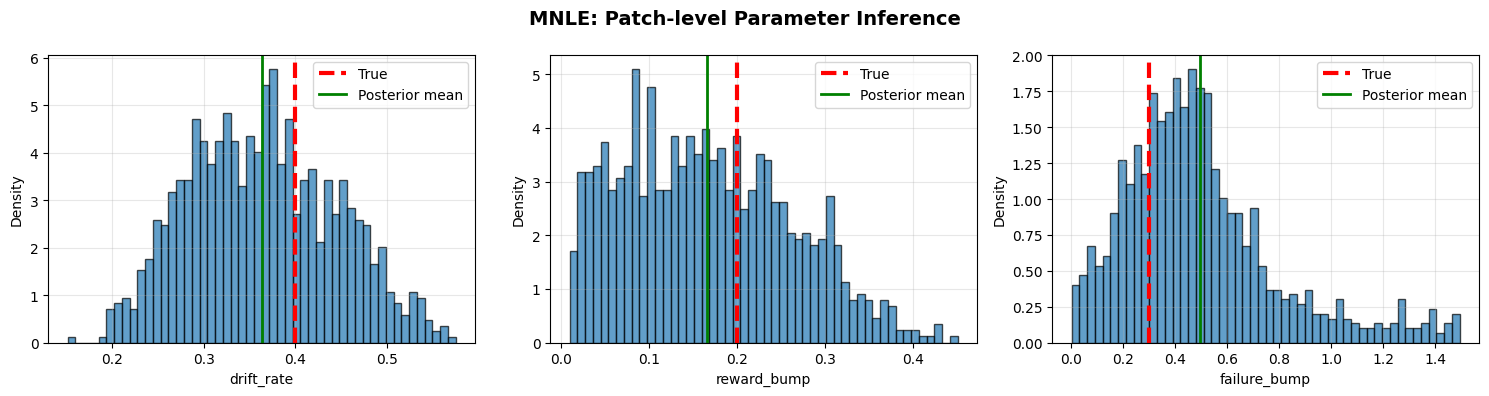

In [4]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
param_names = ['drift_rate', 'reward_bump', 'failure_bump']

for i, (ax, name) in enumerate(zip(axes, param_names)):
    ax.hist(posterior_samples_multi[:, i].numpy(), bins=50, 
            density=True, alpha=0.7, edgecolor='black')
    ax.axvline(true_theta[i].item(), color='red', 
                linestyle='--', linewidth=3, label='True')
    ax.axvline(posterior_mean[i].item(), color='green', 
                linestyle='-', linewidth=2, label='Posterior mean')
    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('MNLE: Patch-level Parameter Inference', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_21991/1973464683.py:7: DeprecationWarning: you passed deprecated arguments **kwargs: ['kde_offdiag', 'kde_diag', 'contour_offdiag', 'points_colors', 'points_offdiag'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, ax = pairplot(


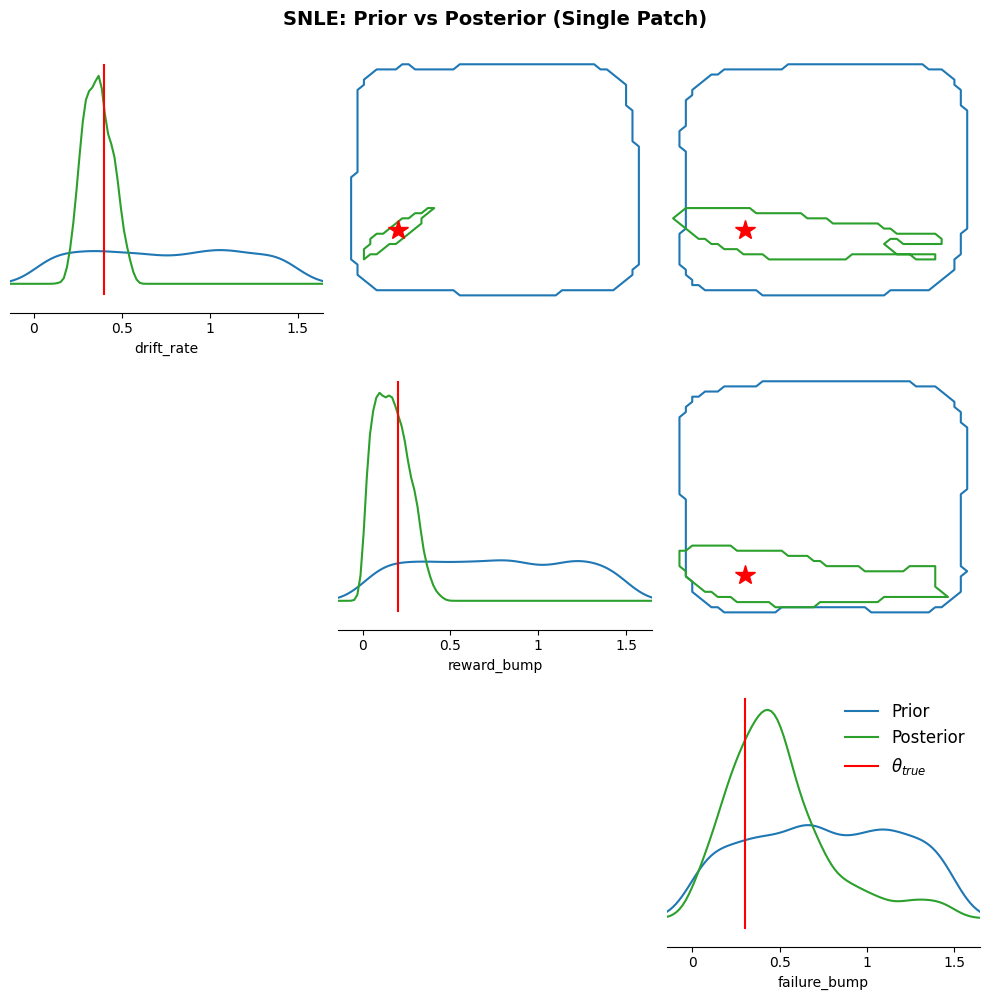

In [5]:
from sbi.analysis import pairplot

# Generate prior samples for comparison
prior_samples = prior.sample((1000,))

# Create pairplot comparing prior and posterior
fig, ax = pairplot(
    [prior_samples, posterior_samples_multi],
    points=true_theta,  # True parameters as a point
    diag="kde",
    upper="contour", 
    kde_offdiag=dict(bins=50),
    kde_diag=dict(bins=100),
    contour_offdiag=dict(levels=[0.95]),
    points_colors=["red"], 
    points_offdiag=dict(marker="*", markersize=15), 
    labels=[r"drift_rate", r"reward_bump", r"failure_bump"],
    figsize=(10, 10)
)

# Add legend
plt.sca(ax[2, 2])  # Select the bottom-right subplot
plt.legend(
    ["Prior", "Posterior", r"$\theta_{true}$"], 
    frameon=False, 
    fontsize=12,
    loc='upper right'
)

plt.suptitle('SNLE: Prior vs Posterior (Single Patch)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [6]:
import numpy as np

# Generate multiple patches from posterior samples to compare distributions
print("\nGenerating patches from posterior samples for comparison...")

num_comparison_patches = 100

# 1. Generate "real" data from true simulator with true parameters
real_patches = []
for _ in range(num_comparison_patches):
    global_time = 0.0
    patch_start_time = 0.0
    _, _, stats = simulator._simulate_one_patch(true_theta, global_time, patch_start_time)
    real_patches.append(stats)
real_data = torch.stack(real_patches)

# 2. Generate "synthetic" data from simulator using posterior-sampled parameters
synthetic_patches = []
for i in range(num_comparison_patches):
    # Sample a parameter from posterior
    theta_sample = posterior_samples_multi[i % len(posterior_samples_multi)]
    
    global_time = 0.0
    patch_start_time = 0.0
    _, _, stats = simulator._simulate_one_patch(theta_sample, global_time, patch_start_time)
    synthetic_patches.append(stats)
synthetic_data = torch.stack(synthetic_patches)

print(f"Real data shape: {real_data.shape}")
print(f"Synthetic data shape: {synthetic_data.shape}")


Generating patches from posterior samples for comparison...
Real data shape: torch.Size([100, 3])
Synthetic data shape: torch.Size([100, 3])


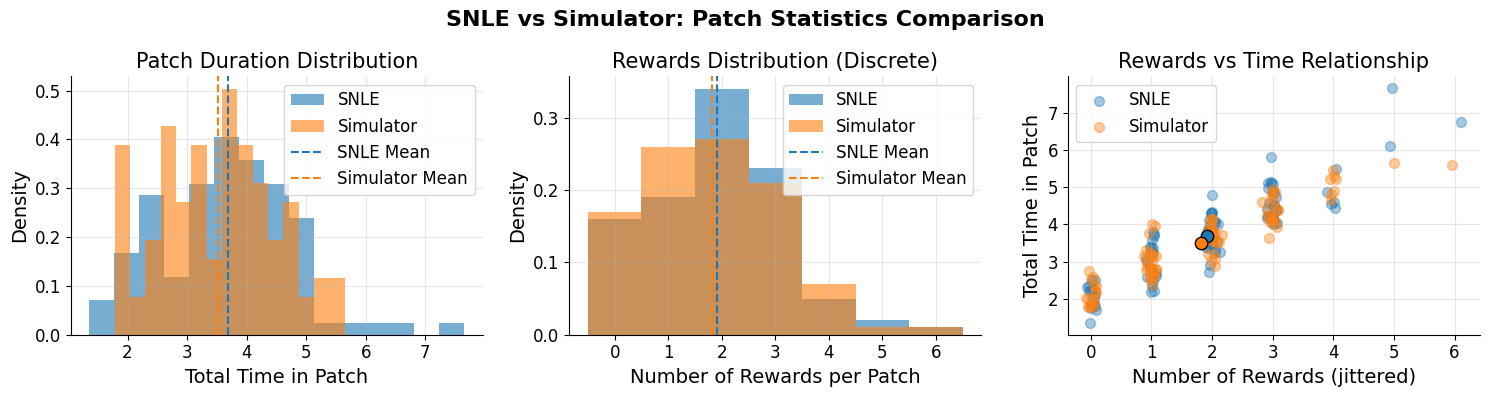


COMPARISON SUMMARY

Total Time in Patch:
  SNLE:      3.686 ± 1.123
  Simulator: 3.513 ± 0.973

Number of Stops:
  SNLE:      3.690 ± 1.169
  Simulator: 3.540 ± 1.068

Number of Rewards:
  SNLE:      1.920 ± 1.269
  Simulator: 1.820 ± 1.290


In [7]:
# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Common function to clean up axis look
def clean_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=12)

# --- Plot 1: Time in patch distributions (histogram) ---
axes[0].hist(synthetic_data[:, 0].numpy(), bins=15, alpha=0.6, label='SNLE',
             density=True)
axes[0].hist(real_data[:, 0].numpy(), bins=15, alpha=0.6, label='Simulator',
             density=True)
axes[0].axvline(synthetic_data[:, 0].mean(), color='C0', linestyle='--', label='SNLE Mean')
axes[0].axvline(real_data[:, 0].mean(), color='C1', linestyle='--', label='Simulator Mean')

axes[0].set_xlabel('Total Time in Patch', fontsize=14)
axes[0].set_ylabel('Density', fontsize=14)
axes[0].set_title('Patch Duration Distribution', fontsize=15)
axes[0].legend(fontsize=12)
clean_axis(axes[0])

# --- Plot 2: Rewards per patch (histogram with integer bins) ---
reward_min = int(min(synthetic_data[:, 2].min(), real_data[:, 2].min()))
reward_max = int(max(synthetic_data[:, 2].max(), real_data[:, 2].max()))
bins = np.arange(reward_min - 0.5, reward_max + 1.5, 1)  # centers bins on integers

axes[1].hist(synthetic_data[:, 2].numpy(), bins=bins, alpha=0.6, label='SNLE',
             density=True)
axes[1].hist(real_data[:, 2].numpy(), bins=bins, alpha=0.6, label='Simulator',
             density=True)
axes[1].axvline(synthetic_data[:, 2].mean(), color='C0', linestyle='--', label='SNLE Mean')
axes[1].axvline(real_data[:, 2].mean(), color='C1', linestyle='--', label='Simulator Mean')

axes[1].set_xlabel('Number of Rewards per Patch', fontsize=14)
axes[1].set_ylabel('Density', fontsize=14)
axes[1].set_title('Rewards Distribution (Discrete)', fontsize=15)
axes[1].legend(fontsize=12)
clean_axis(axes[1])

# --- Plot 3: Rewards vs Time scatter ---
axes[2].scatter(
    synthetic_data[:, 2].numpy() + np.random.normal(0, 0.05, num_comparison_patches),
    synthetic_data[:, 0].numpy(),
    alpha=0.4, label='SNLE', s=50
)
axes[2].scatter(
    real_data[:, 2].numpy() + np.random.normal(0, 0.05, num_comparison_patches),
    real_data[:, 0].numpy(),
    alpha=0.4, label='Simulator', s=50
)

# Mean markers
axes[2].scatter(synthetic_data[:, 2].mean(), synthetic_data[:, 0].mean(),
                color='C0', edgecolor='black', s=80, zorder=5)
axes[2].scatter(real_data[:, 2].mean(), real_data[:, 0].mean(),
                color='C1', edgecolor='black', s=80, zorder=5)

axes[2].set_xlabel('Number of Rewards (jittered)', fontsize=14)
axes[2].set_ylabel('Total Time in Patch', fontsize=14)
axes[2].set_title('Rewards vs Time Relationship', fontsize=15)
axes[2].legend(fontsize=12)
clean_axis(axes[2])

plt.suptitle('SNLE vs Simulator: Patch Statistics Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"\nTotal Time in Patch:")
print(f"  SNLE:      {synthetic_data[:, 0].mean():.3f} ± {synthetic_data[:, 0].std():.3f}")
print(f"  Simulator: {real_data[:, 0].mean():.3f} ± {real_data[:, 0].std():.3f}")
print(f"\nNumber of Stops:")
print(f"  SNLE:      {synthetic_data[:, 1].mean():.3f} ± {synthetic_data[:, 1].std():.3f}")
print(f"  Simulator: {real_data[:, 1].mean():.3f} ± {real_data[:, 1].std():.3f}")
print(f"\nNumber of Rewards:")
print(f"  SNLE:      {synthetic_data[:, 2].mean():.3f} ± {synthetic_data[:, 2].std():.3f}")
print(f"  Simulator: {real_data[:, 2].mean():.3f} ± {real_data[:, 2].std():.3f}")
print("="*60)

In [8]:
np.shape(synthetic_data)

torch.Size([100, 3])

In [9]:
import numpy as np

# Generate multiple patches from posterior samples to compare distributions
print("\nGenerating patches from posterior samples for comparison...")

num_comparison_patches = 100
real_data = []
synthetic_data = []

for i in range(num_comparison_patches):
    # 1. Generate "real" data from true simulator with true parameters
    param_gen = simulator.walk_params(true_theta)
    _, real_data_sample = simulator.simulate_trial(param_gen, 100, return_aggregate=True)
    real_data.append(real_data_sample)

    # 2. Generate "synthetic" data from simulator using posterior-sampled parameters
    theta_sample = posterior_samples_multi[i % len(posterior_samples_multi)]
    param_gen = simulator.walk_params(theta_sample)
    _, synthetic_data_sample = simulator.simulate_trial(param_gen, 100, return_aggregate=True)
    synthetic_data.append(synthetic_data_sample)

# Convert to numpy arrays (in case they are still lists or torch tensors)
real_data = np.array(real_data)
synthetic_data = np.array(synthetic_data)

print(f"Real data shape: {(real_data).shape}")
print(f"Synthetic data shape: {(synthetic_data).shape}")


Generating patches from posterior samples for comparison...
Real data shape: (100, 8)
Synthetic data shape: (100, 8)


Binning for stat index 0: bins=30
Binning for stat index 1: bins=30
Binning for stat index 2: bins=30
Binning for stat index 3: bins=30
Binning for stat index 4: bins=30
Binning for stat index 5: bins=30
Binning for stat index 6: bins=[41.5 42.5 43.5 44.5 45.5 46.5 47.5 48.5 49.5 50.5 51.5 52.5 53.5 54.5
 55.5 56.5 57.5 58.5 59.5 60.5 61.5 62.5 63.5 64.5 65.5]
Binning for stat index 7: bins=[22.5 23.5 24.5 25.5 26.5 27.5 28.5 29.5 30.5 31.5 32.5 33.5 34.5]


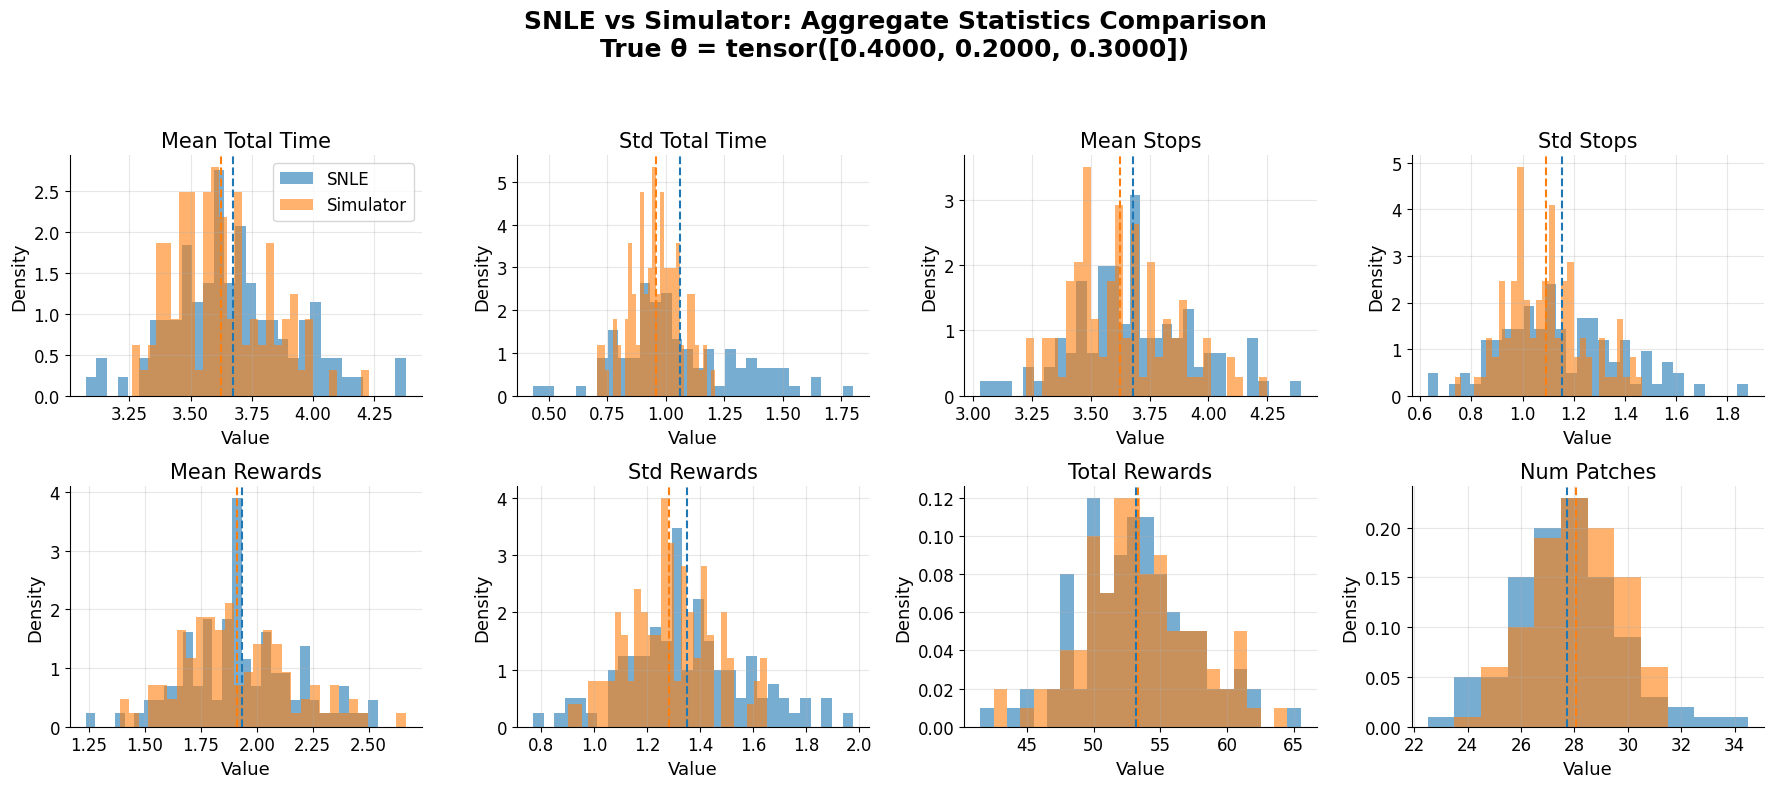

In [10]:
# Labels for the 8 statistics
stat_labels = [
    "Mean Total Time",
    "Std Total Time",
    "Mean Stops",
    "Std Stops",
    "Mean Rewards",
    "Std Rewards",
    "Total Rewards",
    "Num Patches"
]

# Identify discrete-valued stats (for integer bins)
discrete_indices = [6, 7]

# ------------------------------------------------------------
# FIGURE 1: Summary histograms (2x4 grid)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

def clean_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=12)

for i, ax in enumerate(axes):
    real_vals = real_data[:, i]
    synth_vals = synthetic_data[:, i]

    # Set bins
    if i in discrete_indices:
        val_min = int(min(real_vals.min(), synth_vals.min()))
        val_max = int(max(real_vals.max(), synth_vals.max()))
        bins = np.arange(val_min - 0.5, val_max + 1.5, 1)
    else:
        bins = 30
    print(f"Binning for stat index {i}: bins={bins}")
    ax.hist(synth_vals, bins=bins, alpha=0.6, label="SNLE", density=True)
    ax.hist(real_vals, bins=bins, alpha=0.6, label="Simulator", density=True)
    ax.axvline(np.mean(synth_vals), color='C0', linestyle='--')
    ax.axvline(np.mean(real_vals), color='C1', linestyle='--')

    ax.set_title(stat_labels[i], fontsize=15)
    ax.set_xlabel("Value", fontsize=13)
    ax.set_ylabel("Density", fontsize=13)
    clean_axis(ax)

axes[0].legend(fontsize=12)
plt.suptitle(f"SNLE vs Simulator: Aggregate Statistics Comparison\nTrue θ = {np.round(true_theta, 3)}",
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

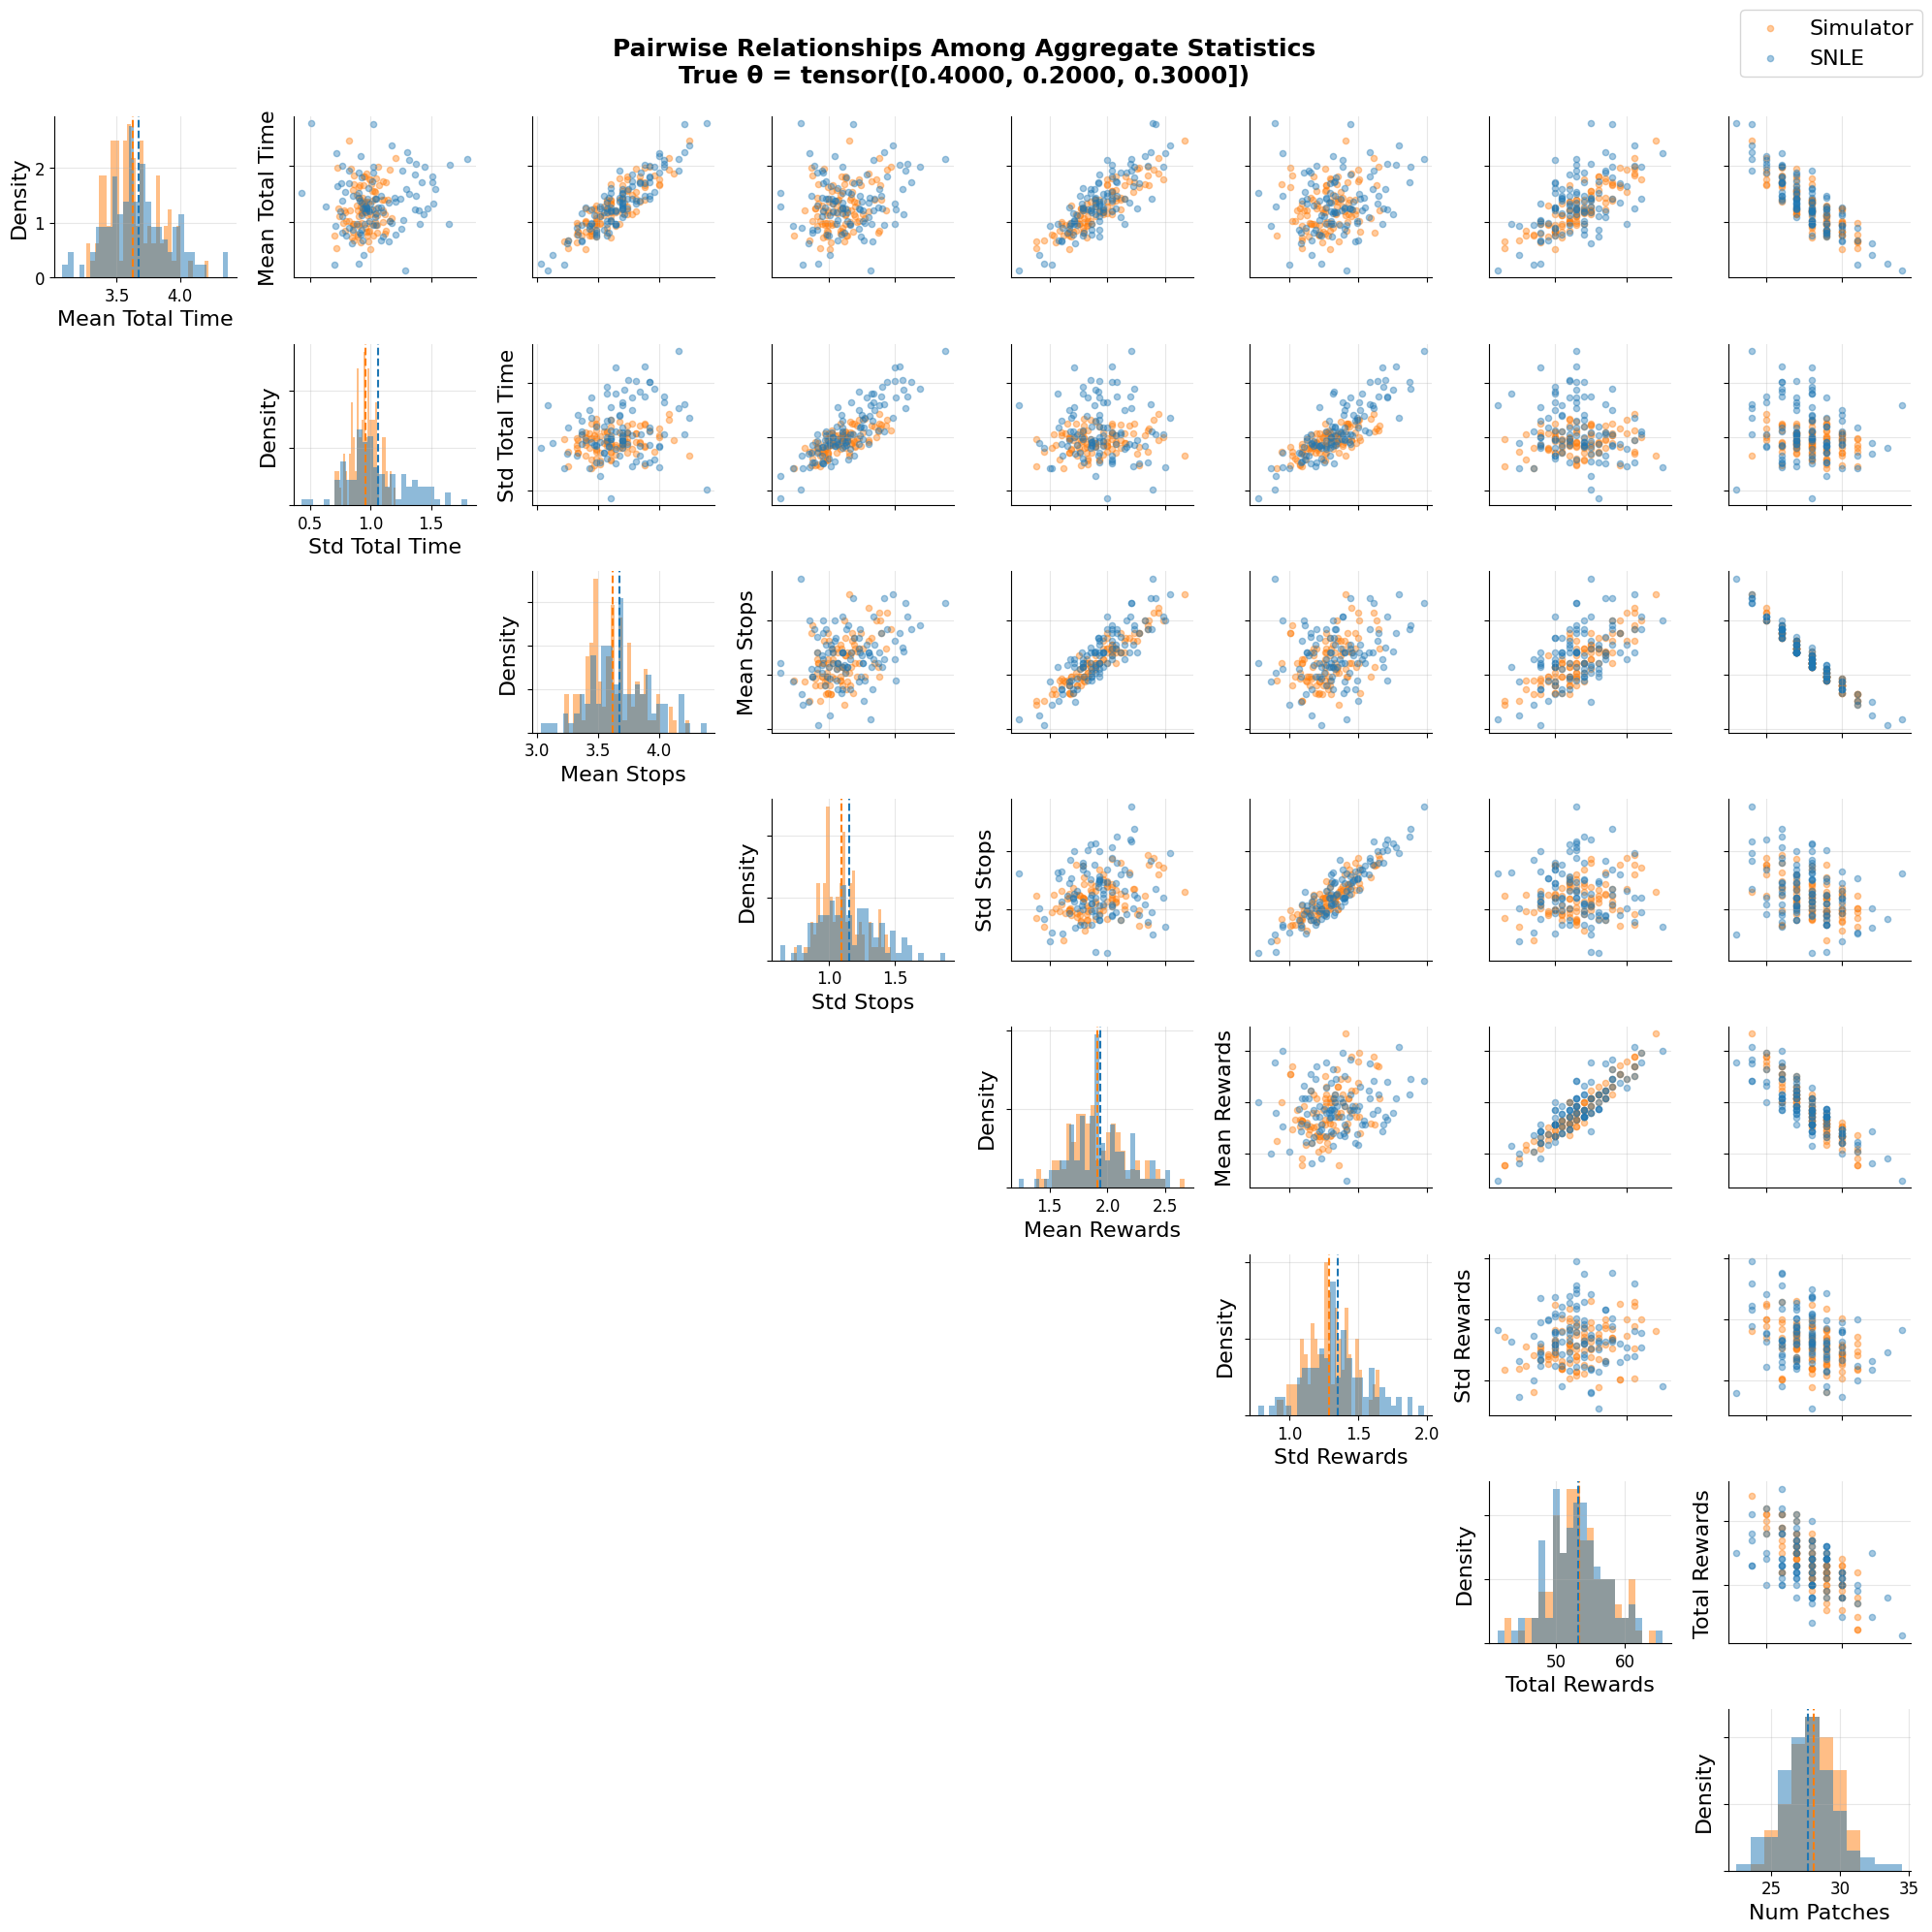

In [11]:
# ------------------------------------------------------------
# FIGURE 2: 8x8 Upper-Triangular Scatter Matrix (diagonal x-axis labels)
# ------------------------------------------------------------
fig, axes = plt.subplots(8, 8, figsize=(20, 20))
fontsize = 16

for i in range(8):
    for j in range(8):
        ax = axes[i, j]
        clean_axis(ax)

        if j < i:
            # Lower triangle: hide axes
            ax.set_visible(False)
            continue

        elif j == i:
            # Diagonal: histogram for that variable

            # Set bins
            real_vals = real_data[:, i]
            synth_vals = synthetic_data[:, i]

            # Set bins
            if i in discrete_indices:
                val_min = int(min(real_vals.min(), synth_vals.min()))
                val_max = int(max(real_vals.max(), synth_vals.max()))
                bins = np.arange(val_min - 0.5, val_max + 1.5, 1)
            else:
                bins = 30

            ax.hist(real_data[:, i], bins=bins, alpha=0.5, color='C1', density=True)
            ax.hist(synthetic_data[:, i], bins=bins, alpha=0.5, color='C0', density=True)
            ax.axvline(np.mean(real_data[:, i]), color='C1', linestyle='--')
            ax.axvline(np.mean(synthetic_data[:, i]), color='C0', linestyle='--')
            # Add x-axis label
            ax.set_xlabel(stat_labels[i], fontsize=fontsize)
        else:
            # Upper triangle: scatter plot
            ax.scatter(real_data[:, j], real_data[:, i],
                       alpha=0.4, color='C1', s=20, label='Simulator' if (i, j) == (0, 1) else "")
            ax.scatter(synthetic_data[:, j], synthetic_data[:, i],
                       alpha=0.4, color='C0', s=20, label='SNLE' if (i, j) == (0, 1) else "")

        # Hide inner tick labels
        if i != 7 and j != i:
            ax.set_xticklabels([])
        if j != 0:
            ax.set_yticklabels([])

# Add y-axis labels on the leftmost column
for k in range(8):
    axes[k, k].set_ylabel('Density', fontsize=fontsize)
    if k<7:
        axes[k, k+1].set_ylabel(stat_labels[k], fontsize=fontsize)

# Shared legend
handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=fontsize)

plt.suptitle(f"Pairwise Relationships Among Aggregate Statistics\nTrue θ = {np.round(true_theta, 3)}",
             fontsize=fontsize+2, fontweight='bold', y=.98)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
